# **1. Cargar imagen**

In [9]:
# Importar librerías
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Cargar imagen a color y en escala de grises
imagen = cv2.imread("/content/com329329-x-ray-1704855_1920.jpg")
imagen_gris = cv2.imread("/content/com329329-x-ray-1704855_1920.jpg", 0)

# Obtención de las dimensiones en ambas imágenes
dimensiones = imagen.shape
print(f"Las dimensiones de la imagen a color son: {dimensiones}")

dimensiones_gris = imagen_gris.shape
print(f"Las dimensiones de la imagen en escala de grises son: {dimensiones_gris}")

Las dimensiones de la imagen a color son: (1920, 1597, 3)
Las dimensiones de la imagen en escala de grises son: (1920, 1597)


En este primer bloque, se importaron las librerias de OpenCV, Matplotlib y Numpy para hacer uso de ellos durante todo el desarrollo del código.

Primeramente se cargó la imagen de una radiografía de una mano por medio de la función "cv2.imread()" y se obtuvo la imagen tanto en su versión a color como en escala de grises.

Posteriormente, se obtuvieron las dimensiones de ambas imágenes, imprimiendo el resultado de ambas.

# **2. Preprocesamiento**

In [10]:
# Conversión de la imagen a color a escala de grises
imagen_escala_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

# Ajuste de brillo y contraste por medio de una ecualización
ecualizacion = cv2.equalizeHist(imagen_escala_gris)

Para este segundo bloque, por medio de la función "cv2.cvtColor()" se convirtió la imagen a color en una imagen a escala de grises.

Después, para un ajuste de brillo y contraste en toda la imagen, se utilizó como primer método la ecualización de histograma, guardando dicho ajuste en la variable "ecualización".

In [11]:
# Ajuste de contraste por medio de una multiplicación
contraste = cv2.multiply(imagen_escala_gris, 1.6)

# Ajuste de brillo a la imagen con el contraste ajustado por medio de una suma
imagen_preprocesada = cv2.add(contraste, 100)

Como segundo método para el ajuste de brillo y contraste en la imagen, se utilizaron operaciones aritméticas, más específicamente la multiplicación (el cual afecta el contraste) y la suma (el cual afecta al brillo).

Ambas operaciones fueron utilizados con la función "multiply()" y "add()".

# **3. Segmentación**

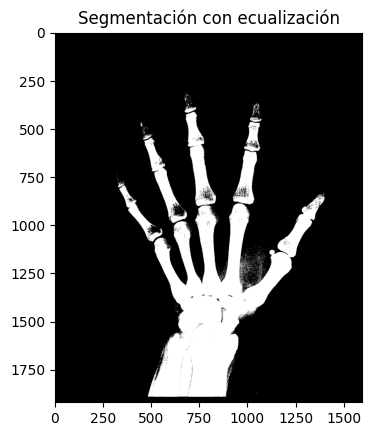

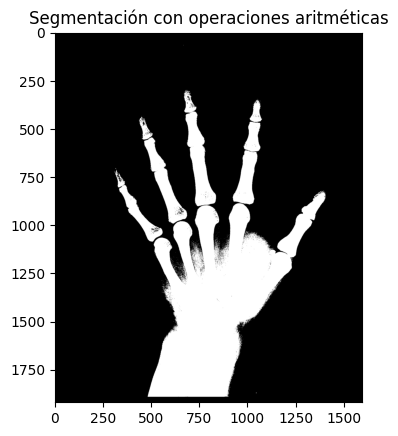

In [12]:
# Umbralización de la imagen ecualizada
imagen_segmentada = cv2.threshold(ecualizacion, 210, 255, cv2.THRESH_BINARY)
# Umbralización de la imagen ajustada con operaciones aritméticas
imagen2_segmentada = cv2.threshold(imagen_preprocesada, 210, 255, cv2.THRESH_BINARY)

# Separación de los canales RGB
b, g, r = cv2.split(imagen)

# Imagen segmentada por ecualización
plt.title("Segmentación con ecualización")
plt.imshow(imagen_segmentada[1], cmap = "gray")
plt.show()

# Imagen segmentada por operaciones aritméticas
plt.title("Segmentación con operaciones aritméticas")
plt.imshow(imagen2_segmentada[1], cmap = "gray")
plt.show()

Para el tercer bloque se realizó la umbralización de la imagen obtenida con el método de ecualización de histograma y el de operaciones aritméticas por medio de la función "cv2.threshold()" colocando un valor de umbral de 210 para ambos métodos y mostrando los resultados con funciones provenientes de Matplotlib.

Asimismo, se separaron los canales de la imagen RGB con la función cv2."split()" en variables denominadas como "b", "g" y "r".

# **4. Análisis de características**

El área del objeto segmentado por ecualización es de: 460500
El área del objeto segmentado por operaciones aritméticas 569886


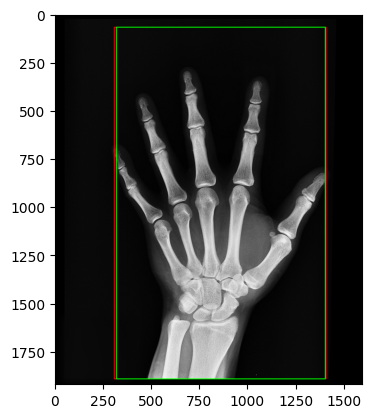

In [14]:
# Obtención del área del objeto segmentado
area = np.count_nonzero(imagen_segmentada[1])
print(f"El área del objeto segmentado por ecualización es de: {area}")

area2 = np.count_nonzero(imagen2_segmentada[1])
print(f"El área del objeto segmentado por operaciones aritméticas {area2}")

# Extraer el contorno rectangular
x, y, w, h = cv2.boundingRect(imagen_segmentada[1])

# Dibujar el contorno
cv2.rectangle(imagen, (x, y), (x + w, y + h), (0, 255, 0), 4)

plt.imshow(imagen)
plt.show()

Para el último bloque, se obtuvo el área de la imagen una vez se encontraba segmentada con ayuda de la función "np.count_nonzero()" de la librería Numpy el cual cuenta cualquier pixel que sea distinto de cero. Esto se hizo para la imagen 1 (ecualización) y la imagen 2 (operaciones aritméticas).

Después de esto, generamos un "bounding box" o una caja delimitadora que va a encerrar el objeto del imagen que se desea analizar. Para esto, primero utilizamos la función "cv2.boundingRect()" al cual le pasamos cualquiera de las 2 imágenes segmentadas que previamente obtuvimos. Los valores de dicha función se guardarán en 4 variables: "x", "y", "w" y "h". Coordenadas en el eje x, eje y, ancho y altura respectivamente.

Con los valores almacenados en las 4 variables usamos la función "cv2.rectangle()" para dibujar el "bounding box" en la imagen original. El color del rectángulo puede cambiar en base a los valores RGB que le proporcionemos a la función.

Viendo detenidamente la imagen con el "bounding box" generado, el de color verde representa el que se realizó tomando en cuenta la imagen segmentada con la ecualización del histograma y la de color rojo aquella realizada con operaciones aritméticas.

El método que terminó dando mejores resultados fue el de operaciones aritméticas debido a los ajustes precisos que se pueden realizar tanto de brillo como de contraste, pudiendo hacer ajustes finos a la imagen sin la necesidad de modificar la umbralización.

Esta ventaja de las operaciones aritméticas permitió que al momento de trazar el "bounding box" no se perdiera tanta información como pasó con la ecualización.